In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os, sys 
import re
import ROOT
import glob

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
colors = {'PAS1': '#FFCB01','PBS1': '#02FD01','PCS1': '#FF00FE','PDS1': '#0300FE','PES1': '#03FDFF','PFS1': '#FF0001',
          'PAS2': '#990099','PBS2': '#039704','PCS2': '#FF9701','PDS2': '#3766CD','PES2': '#990004','PFS2': '#969901',
          'QIS1': '#CC5FCA','QIS2': '#E1A1A7','QOS1': '#5DC75E','QOS2': '#6EC9C5'}

In [3]:
def fetch_data(year, month, day, hour, minute, PSD=False):

    filepath = '/sdf/data/supercdms/workarea/analysis/SNOLAB-commissioning/PulseDisplaySavedData/'+year+month+day+'/'
    if PSD:
        filename_pattern = year+month+day+'_'+hour+minute+'_(?P<zone>Z\d+)(?P<code>[A-Z]+\d+)PSD\.txt$'
    else:
        filename_pattern = year+month+day+'_'+hour+minute+'_(?P<zone>Z\d+)(?P<code>[A-Z]+\d+)\.txt$'
    filename_wildcard = year+month+day+'_'+hour+minute+'_*.txt'
    files = np.sort(glob.glob(filepath+filename_wildcard))
    pattern = re.compile(filepath+filename_pattern)
    matches = [pattern.match(f).groups() for f in files if pattern.match(f)]

    df = {m[1]: {'x': None, 'y': None} for m in matches}

    for i, file in enumerate(files):
        data = np.loadtxt(file)
        bin_start = data[:,0]
        bin_width = data[:,2]
        y = data[:,1]
        x = bin_start + 0.5 * bin_width
        df[matches[i][1]]['x'] = x
        df[matches[i][1]]['y'] = y

    return df, matches

T1P1 traces with different HEMT configurations

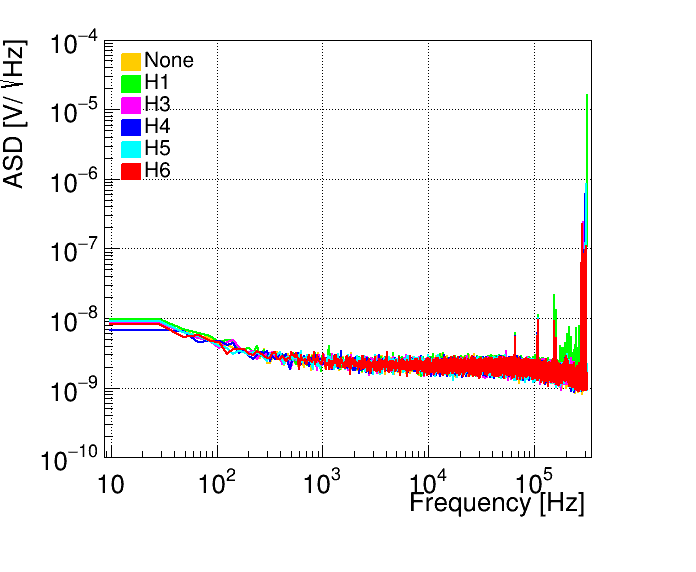

In [4]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '07', '10', '09', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '05', PSD=True) # H1

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '13', PSD=True) # H3

color = ROOT.TColor.GetColor(colors['PCS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H3', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '17', PSD=True) # H4

color = ROOT.TColor.GetColor(colors['PDS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H4', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '21', PSD=True) # H5

color = ROOT.TColor.GetColor(colors['PES1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H5', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '24', PSD=True) # H5

color = ROOT.TColor.GetColor(colors['PFS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H6', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.68, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


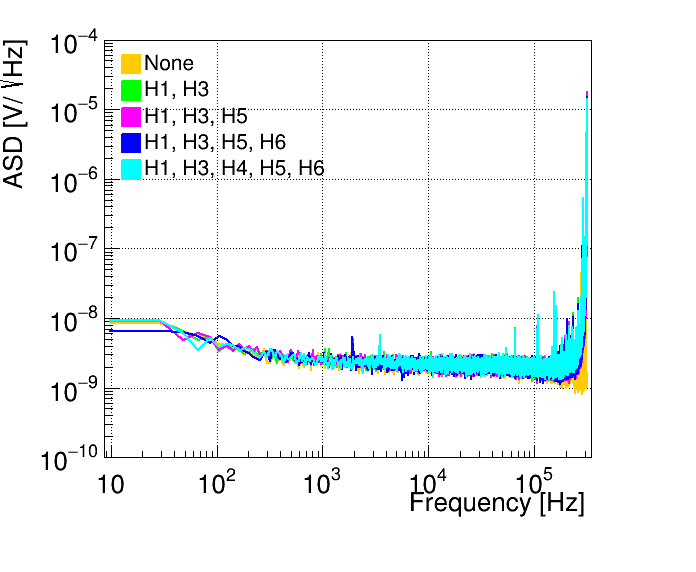

In [5]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '07', '10', '09', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '39', PSD=True) # H1, H3

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '51', PSD=True) # H1, H3, H5

color = ROOT.TColor.GetColor(colors['PCS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H5', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '10', '58', PSD=True) # H1, H3, H5, H6

color = ROOT.TColor.GetColor(colors['PDS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H5, H6', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '11', '06', PSD=True) # H1, H3, H4, H5, H6

color = ROOT.TColor.GetColor(colors['PES1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H4, H5, H6', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.68, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


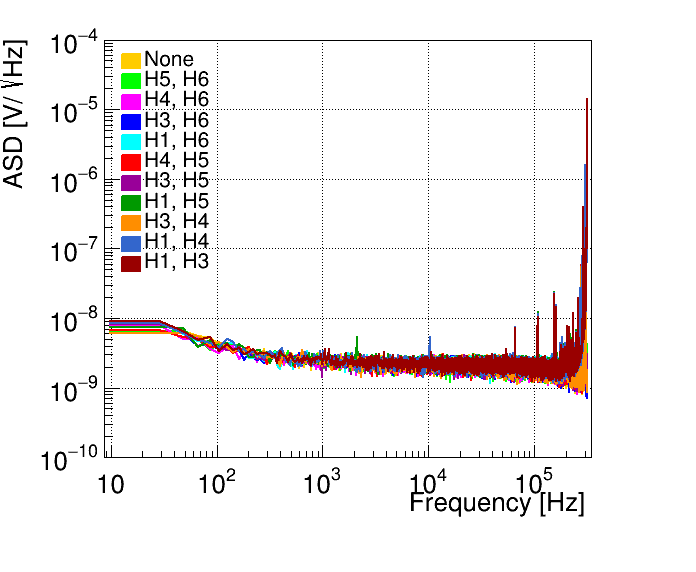

In [6]:
chan = 'PFS2'
size = 2
alpha = 1

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '07', '10', '09', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'None', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '17', PSD=True) # H5, H6

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H5, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '20', PSD=True) # H4, H6

color = ROOT.TColor.GetColor(colors['PCS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H4, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '23', PSD=True) # H3, H6

color = ROOT.TColor.GetColor(colors['PDS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '28', PSD=True) # H1, H6

color = ROOT.TColor.GetColor(colors['PES1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '31', PSD=True) # H4, H5

color = ROOT.TColor.GetColor(colors['PFS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H4, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '34', PSD=True) # H3, H5

color = ROOT.TColor.GetColor(colors['PAS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '36', PSD=True) # H1, H5

color = ROOT.TColor.GetColor(colors['PBS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '41', PSD=True) # H3, H4

color = ROOT.TColor.GetColor(colors['PCS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H4', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '11', '54', PSD=True) # H1, H4

color = ROOT.TColor.GetColor(colors['PDS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H4', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '10', '39', PSD=True) # H1, H3

color = ROOT.TColor.GetColor(colors['PES2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H3', color = color, alpha = alpha)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.52, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

T1P2 traces with different HEMT configurations

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


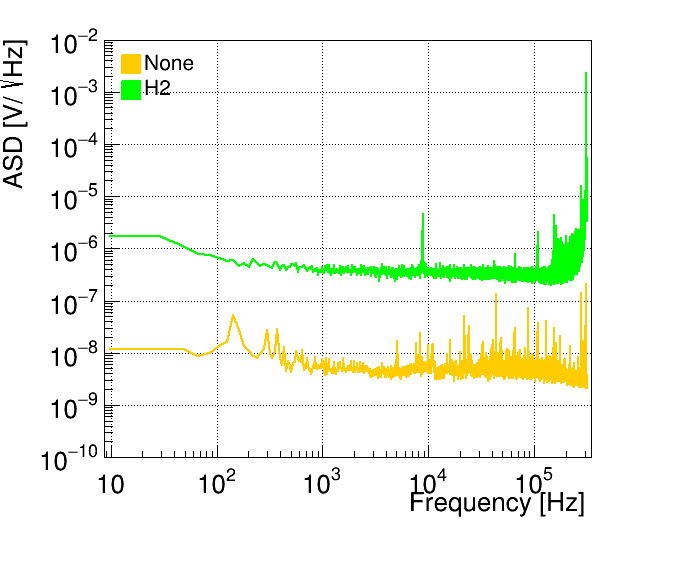

In [23]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-2)

df, matches = fetch_data('2026', '01', '06', '11', '42', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '08', '09', '49', PSD=True) # H2

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H2', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.82, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

T1P3 traces with different HEMT configurations

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


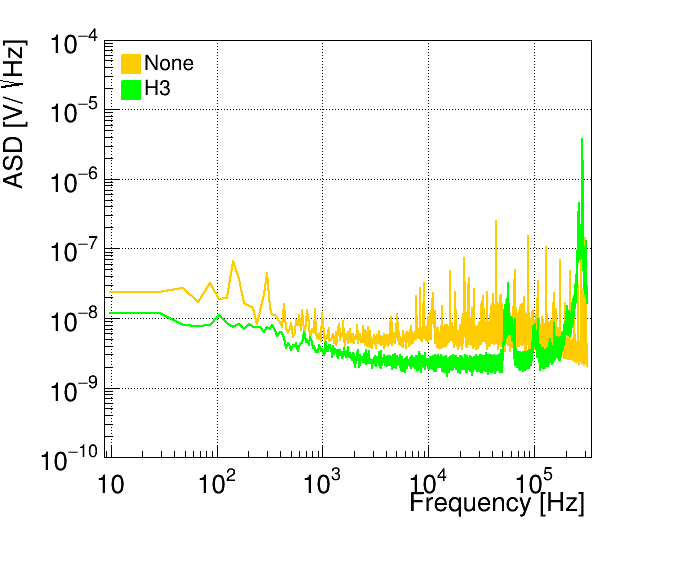

In [58]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '06', '11', '53', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '12', '34', PSD=True) # H3

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H3', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.82, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


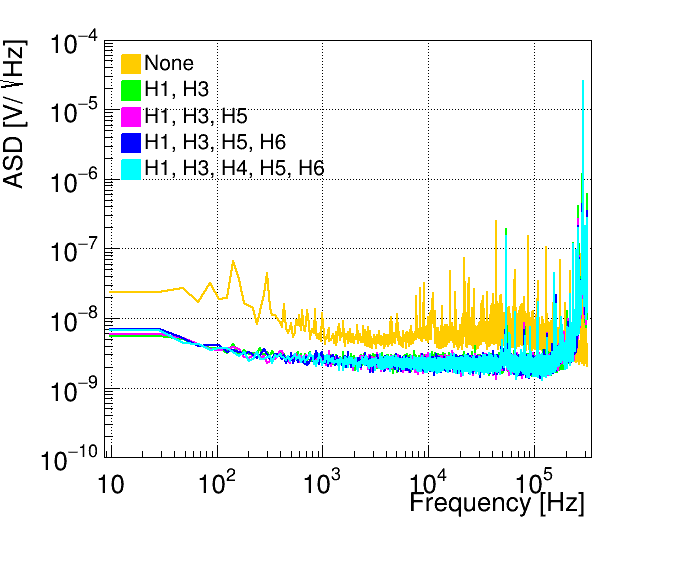

In [59]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '06', '11', '53', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '12', '59', PSD=True) # H1, H3

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '13', '04', PSD=True) # H1, H3, H5

color = ROOT.TColor.GetColor(colors['PCS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H5', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '13', '07', PSD=True) # H1, H3, H5, H6

color = ROOT.TColor.GetColor(colors['PDS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H5, H6', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '07', '13', '11', PSD=True) # H1, H3, H4, H5, H6

color = ROOT.TColor.GetColor(colors['PES1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H1, H3, H4, H5, H6', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.68, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


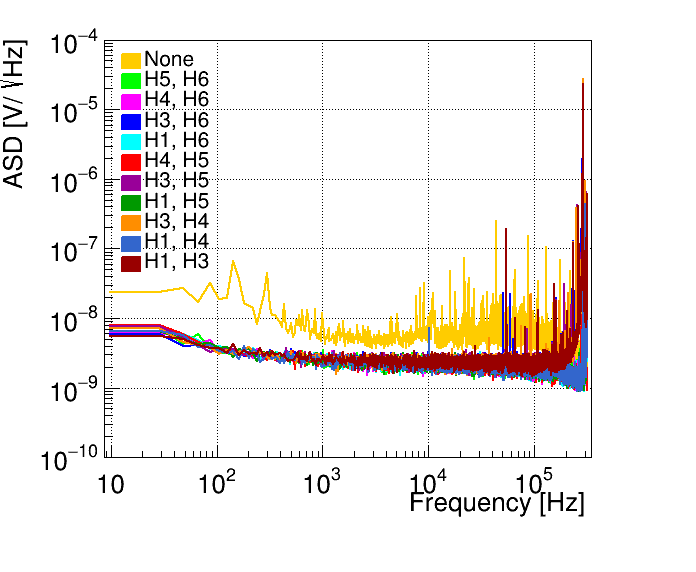

In [60]:
chan = 'PFS2'
size = 2
alpha = 1

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-4)

df, matches = fetch_data('2026', '01', '06', '11', '53', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'None', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '16', PSD=True) # H5, H6

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H5, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '18', PSD=True) # H4, H6

color = ROOT.TColor.GetColor(colors['PCS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H4, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '20', PSD=True) # H3, H6

color = ROOT.TColor.GetColor(colors['PDS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '23', PSD=True) # H1, H6

color = ROOT.TColor.GetColor(colors['PES1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H6', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '26', PSD=True) # H4, H5

color = ROOT.TColor.GetColor(colors['PFS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H4, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '28', PSD=True) # H3, H5

color = ROOT.TColor.GetColor(colors['PAS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '32', PSD=True) # H1, H5

color = ROOT.TColor.GetColor(colors['PBS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H5', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '34', PSD=True) # H3, H4

color = ROOT.TColor.GetColor(colors['PCS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H3, H4', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '13', '41', PSD=True) # H1, H4

color = ROOT.TColor.GetColor(colors['PDS2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H4', color = color, alpha = alpha)

df, matches = fetch_data('2026', '01', '07', '12', '59', PSD=True) # H1, H3

color = ROOT.TColor.GetColor(colors['PES2'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = size, label = 'H1, H3', color = color, alpha = alpha)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.52, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

T1P4 traces with different HEMT configurations

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


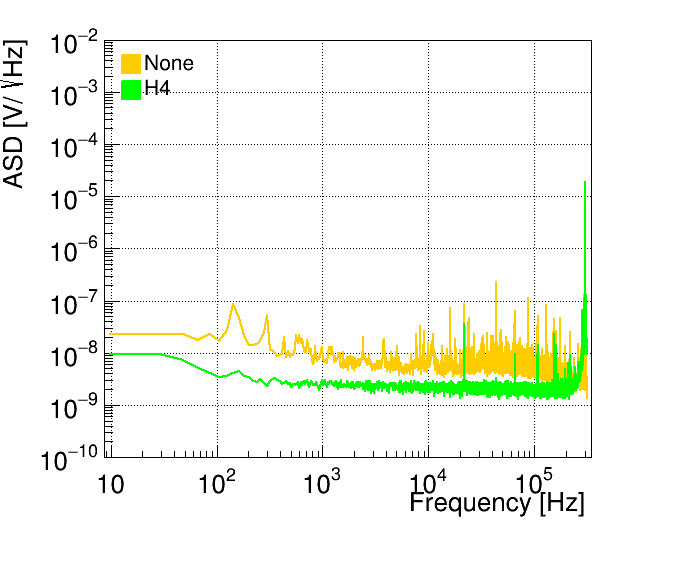

In [73]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-2)

df, matches = fetch_data('2026', '01', '06', '12', '01', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '08', '09', '30', PSD=True) # H4

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H4', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.82, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

T1P5 traces with different HEMT configurations

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


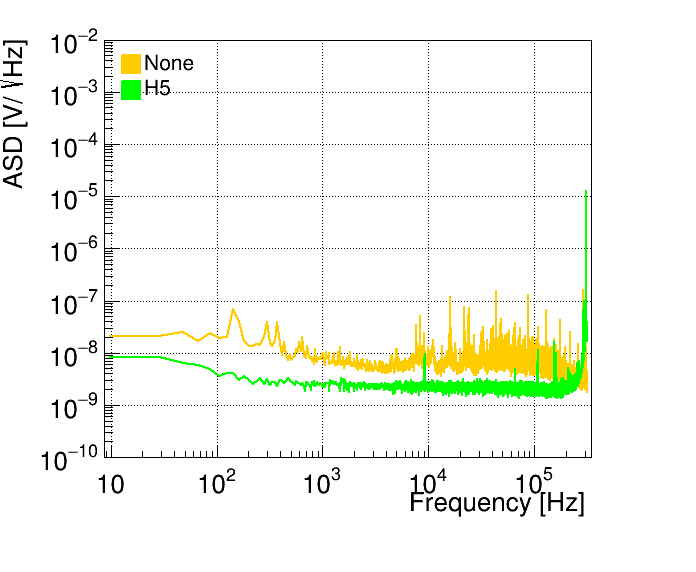

In [85]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-2)

df, matches = fetch_data('2026', '01', '06', '12', '13', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '08', '09', '41', PSD=True) # H5

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H5', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.82, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

T1P6 traces with different HEMT configurations

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


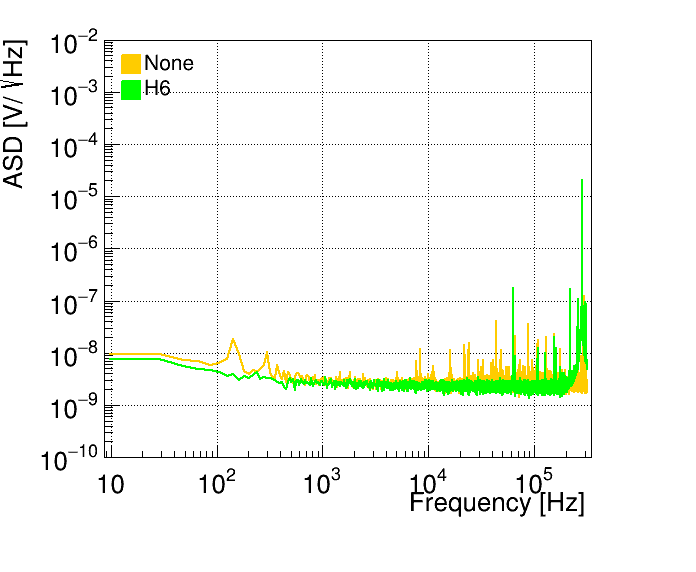

In [100]:
chan = 'PFS2'

plt = ROOplot(_xlabel="Frequency [Hz]", _ylabel="ASD [V/#sqrt{Hz}]", _logx=True, _logy=True, _ylim=True, _ylow=1e-10, _yhigh=1e-2)

df, matches = fetch_data('2026', '01', '06', '12', '21', PSD=True) # HEMTs off

color = ROOT.TColor.GetColor(colors['PAS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'None', color = color, alpha = 1)

df, matches = fetch_data('2026', '01', '08', '09', '19', PSD=True) # H6

color = ROOT.TColor.GetColor(colors['PBS1'])
plt.createScatter(df[chan]['x'], df[chan]['y'].astype(float), size = 2, label = 'H6', color = color, alpha = 1)

plt.draw("AL", "L ", grid=True)
graphs = plt.getGraphs()

legend = ROOT.TLegend(0.17, 0.82, 0.32, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()